In [2]:
from google.colab import files
uploaded = files.upload()

Saving ds-dashboard (2).zip to ds-dashboard (2).zip


# **Hipotesis**

H0: Tidak ada perbedaan tingkat kecocokan pekerjaan antara pengguna yang menggunakan AI CV Review dan yang tidak.

H1: Pengguna yang menggunakan AI CV Review memiliki tingkat kecocokan pekerjaan yang lebih tinggi.

In [3]:
!unzip ds-dashboard\ \(2\).zip

Archive:  ds-dashboard (2).zip
   creating: ds-dashboard/
   creating: ds-dashboard/ds-dashboard/
   creating: ds-dashboard/ds-dashboard/.git/
  inflating: ds-dashboard/ds-dashboard/.git/COMMIT_EDITMSG  
  inflating: ds-dashboard/ds-dashboard/.git/config  
  inflating: ds-dashboard/ds-dashboard/.git/description  
  inflating: ds-dashboard/ds-dashboard/.git/FETCH_HEAD  
  inflating: ds-dashboard/ds-dashboard/.git/HEAD  
   creating: ds-dashboard/ds-dashboard/.git/hooks/
  inflating: ds-dashboard/ds-dashboard/.git/hooks/applypatch-msg.sample  
  inflating: ds-dashboard/ds-dashboard/.git/hooks/commit-msg.sample  
  inflating: ds-dashboard/ds-dashboard/.git/hooks/fsmonitor-watchman.sample  
  inflating: ds-dashboard/ds-dashboard/.git/hooks/post-update.sample  
  inflating: ds-dashboard/ds-dashboard/.git/hooks/pre-applypatch.sample  
  inflating: ds-dashboard/ds-dashboard/.git/hooks/pre-commit.sample  
  inflating: ds-dashboard/ds-dashboard/.git/hooks/pre-merge-commit.sample  
  inflating: 

In [10]:
import numpy as np
import pandas as pd
from statsmodels.stats.proportion import proportions_ztest
import matplotlib.pyplot as plt
from statsmodels.stats.weightstats import ttest_ind

# Reproducible result
np.random.seed(42)

In [6]:
# Simulasi Eksperimen

n_control = 500
n_treatment = 500

# Skor kecocokan rekomendasi kerja (%)
# Grup A = tanpa AI CV Review
match_control = np.random.normal(
    loc=68,
    scale=12,
    size=n_control
)

# Grup B = menggunakan AI CV Review
match_treatment = np.random.normal(
    loc=75,
    scale=11,
    size=n_treatment
)

# Membatasi skor 0-100
match_control = np.clip(match_control, 0, 100)
match_treatment = np.clip(match_treatment, 0, 100)


In [7]:
# Statistik Deskriptif

mean_A = np.mean(match_control)
mean_B = np.mean(match_treatment)

print("=== HASIL EKSPERIMEN WORKAHOLIC ===")
print(f"Rata-rata Match Score Grup A : {mean_A:.2f}%")
print(f"Rata-rata Match Score Grup B : {mean_B:.2f}%")

=== HASIL EKSPERIMEN WORKAHOLIC ===
Rata-rata Match Score Grup A : 68.04%
Rata-rata Match Score Grup B : 75.32%


In [11]:
# Independent T-Test
# ==========================

t_stat, p_value, _ = ttest_ind(
    match_control,
    match_treatment,
    usevar='unequal'
)

print("\n=== HASIL UJI STATISTIK ===")
print(f"T-Statistic : {t_stat:.4f}")
print(f"P-Value     : {p_value:.4f}")

alpha = 0.05

if p_value < alpha:
    print("\nKeputusan: Tolak H0")
    print("AI CV Review memberikan peningkatan signifikan terhadap kualitas rekomendasi pekerjaan.")
else:
    print("\nKeputusan: Gagal menolak H0")
    print("Belum terdapat bukti peningkatan yang signifikan.")



=== HASIL UJI STATISTIK ===
T-Statistic : -10.2943
P-Value     : 0.0000

Keputusan: Tolak H0
AI CV Review memberikan peningkatan signifikan terhadap kualitas rekomendasi pekerjaan.


/tmp/ipykernel_6102/2315231939.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


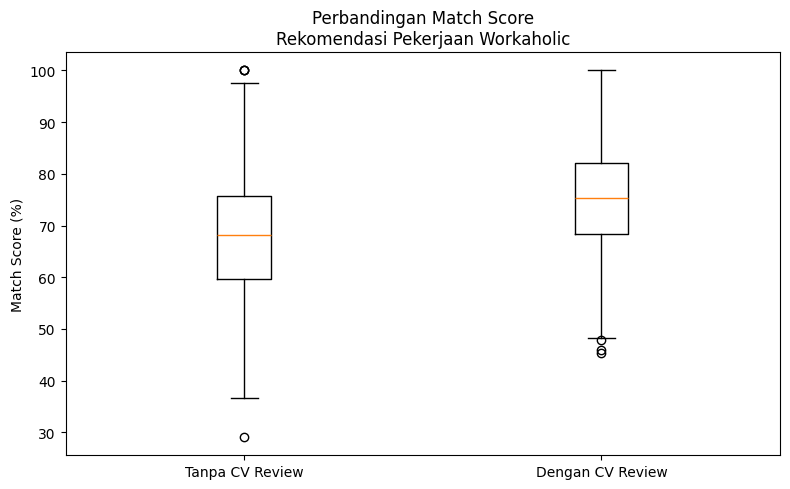

In [13]:

# Visualisasi

plt.figure(figsize=(8,5))

plt.boxplot(
    [match_control, match_treatment],
    labels=['Tanpa CV Review', 'Dengan CV Review']
)

plt.title(
    'Perbandingan Match Score\nRekomendasi Pekerjaan Workaholic'
)

plt.ylabel('Match Score (%)')

plt.tight_layout()
plt.show()

# Intrepetasi
Berdasarkan hasil A/B Testing yang dilakukan pada fitur AI CV Review Workaholic, diperoleh nilai T-Statistic sebesar -10,2943 dan P-Value sebesar 0,0000. Dengan tingkat signifikansi (α) sebesar 0,05, nilai P-Value yang jauh lebih kecil dari 0,05 menunjukkan bahwa hipotesis nol (H0) ditolak.

Hasil ini mengindikasikan adanya perbedaan yang signifikan secara statistik antara kelompok pengguna yang tidak menggunakan AI CV Review dan kelompok pengguna yang menggunakan AI CV Review. Rata-rata Job Match Score pada kelompok yang menggunakan AI CV Review lebih tinggi dibandingkan kelompok kontrol.

Dengan demikian, dapat disimpulkan bahwa fitur AI CV Review mampu meningkatkan kualitas rekomendasi pekerjaan yang diberikan oleh platform Workaholic. Fitur ini membantu pengguna menghasilkan CV yang lebih relevan terhadap kebutuhan industri sehingga sistem dapat memberikan rekomendasi lowongan yang lebih sesuai dengan profil dan keterampilan pengguna.

Temuan ini mendukung tujuan utama Workaholic sebagai platform rekomendasi kerja berbasis AI yang membantu fresh graduate dan pencari kerja entry-level menemukan peluang kerja yang lebih relevan dan meningkatkan kesiapan mereka dalam memasuki dunia kerja.
